## Introdução às redes neurais artificiais -- Perceptron e Adaline

## Porta and

In [2]:
import pandas as pd
import numpy as np

dados=pd.DataFrame({'x1':[0,1,0,1],'x2':[0,0,1,1],'y':[0,0,0,1]})
dados

,x1,x2,y
0,0,0,0
1,1,0,0
2,0,1,0
3,1,1,1


In [3]:
from sklearn.linear_model import Perceptron


per_clf=Perceptron(max_iter=1000,tol=1e-3,random_state=42)
per_clf.fit(dados[['x1','x2']],dados['y'])

print("Perceptron treinado")
print("Os pesos encontrados foram {} e o bias foi {}.".format(per_clf.coef_,per_clf.intercept_))

Perceptron treinado
Os pesos encontrados foram [[2. 2.]] e o bias foi [-3.].


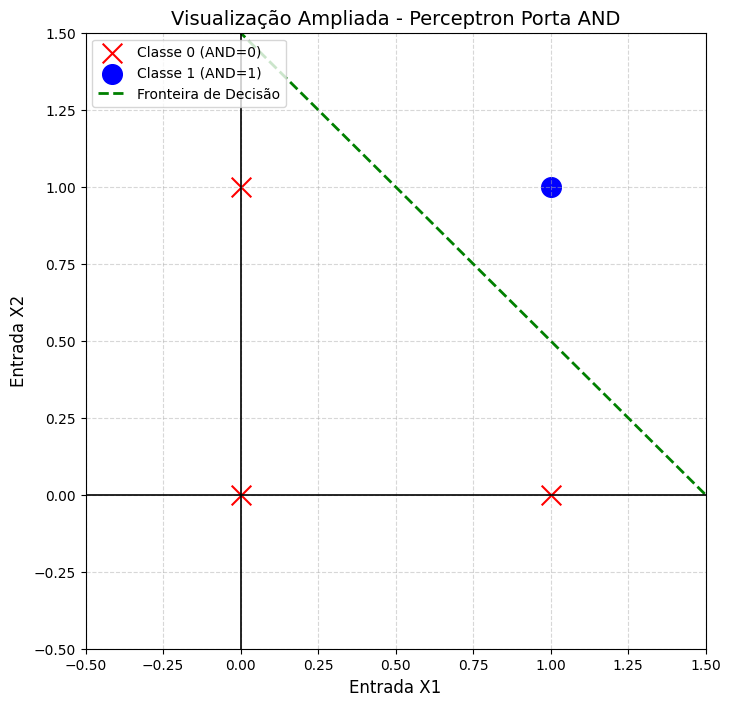

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Extraindo parâmetros do seu modelo per_clf
w1, w2 = per_clf.coef_[0]
bias = per_clf.intercept_[0]

# 2. Criando a linha de decisão com uma amplitude maior
# x2 = -(w1*x1 + bias) / w2
x1_valores = np.linspace(-1, 2, 100)
x2_valores = -(w1 * x1_valores + bias) / w2

# 3. Configuração do Gráfico
plt.figure(figsize=(8, 8))

# Plotando os pontos com cores diferentes para cada classe
for i, row in dados.iterrows():
    if row['y'] == 1:
        plt.scatter(row['x1'], row['x2'], c='blue', marker='o', s=200, label='Classe 1 (AND=1)' if i==3 else "")
    else:
        plt.scatter(row['x1'], row['x2'], c='red', marker='x', s=200, label='Classe 0 (AND=0)' if i==0 else "")

# Plotando a linha de decisão
plt.plot(x1_valores, x2_valores, 'g--', linewidth=2, label='Fronteira de Decisão')

# --- AJUSTE DE ESCALA ---
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
# -------------------------

# Detalhes visuais
plt.title("Visualização Ampliada - Perceptron Porta AND", fontsize=14)
plt.xlabel("Entrada X1", fontsize=12)
plt.ylabel("Entrada X2", fontsize=12)
plt.axhline(0, color='black', linewidth=1.2)
plt.axvline(0, color='black', linewidth=1.2)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper left')

plt.show()

In [5]:
from sklearn.datasets import load_iris

dados_brutos = load_iris()

# Criando o DataFrame com os nomes das colunas corretos
df_iris = pd.DataFrame(data=dados_brutos.data, columns=dados_brutos.feature_names)
df_iris['target'] = dados_brutos.target


X = df_iris[['petal length (cm)', 'petal width (cm)']]
y = df_iris['target']

In [11]:
setosa_versicolor = (df_iris['target'] == 0) | (df_iris['target'] == 1)



[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


## Variáveis do banco de dados:

# 1.petal length in cm
# 2. petal width in cm
# 3. class

# Iris setosa (0)
# Versicolor (1)

In [13]:
modelo_per = Perceptron(max_iter=1000,tol=1e-3,random_state=42)
modelo_per.fit(X[setosa_versicolor],y[setosa_versicolor])

print("Perceptron treinado!!!")
print(f'Os pesos encontrados foram {modelo_per.coef_} e o bias {modelo_per.intercept_}')

Perceptron treinado!!!
Os pesos encontrados foram [[1.5 2.2]] e o bias [-5.]


In [17]:
w1,w2=modelo_per.coef_[0]
bias=modelo_per.intercept_[0]

print('w1: ',w1)
print('w2: ',w2)
print('bias:',bias)

w1:  1.5
w2:  2.1999999999999997
bias: -5.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


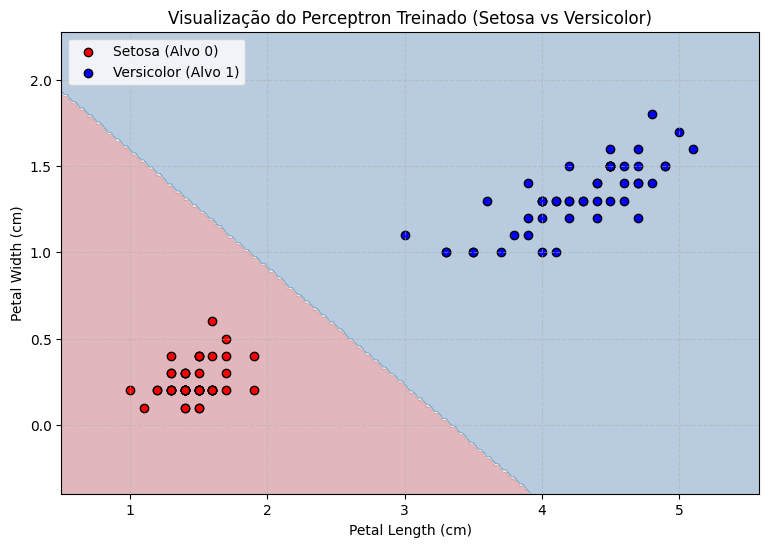

In [18]:
import matplotlib.pyplot as plt

# 1. Preparando os dados filtrados (exatamente como no seu treino)
X_filtrado = X[setosa_versicolor].values
y_filtrado = y[setosa_versicolor].values

# 2. Criando uma grade de pontos para o fundo do gráfico
x_min, x_max = X_filtrado[:, 0].min() - 0.5, X_filtrado[:, 0].max() + 0.5
y_min, y_max = X_filtrado[:, 1].min() - 0.5, X_filtrado[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 3. Usando seu 'modelo_per' para prever a classe de cada ponto da grade
Z = modelo_per.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4. Plotagem
plt.figure(figsize=(9, 6))

# Pinta as áreas de decisão (Fronteira)
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)

# Plota os dados reais fornecidos ao modelo
plt.scatter(X_filtrado[y_filtrado == 0, 0], X_filtrado[y_filtrado == 0, 1],
            c='red', edgecolors='k', label='Setosa (Alvo 0)')
plt.scatter(X_filtrado[y_filtrado == 1, 0], X_filtrado[y_filtrado == 1, 1],
            c='blue', edgecolors='k', label='Versicolor (Alvo 1)')

# Perfumaria (Legendas e Títulos)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Visualização do Perceptron Treinado (Setosa vs Versicolor)')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

